In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

LABEL_MAP = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

train_df = pd.read_parquet("../data/train.parquet")
test_df  = pd.read_parquet("../data/test.parquet")

print(f"Loaded {len(train_df):,} training samples")
print(train_df.head(3))

Loaded 120,000 training samples
                                                text  label label_name
0  Wall St. Bears Claw Back Into the Black (Reute...      2   Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2   Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2   Business


In [7]:
# Start simple — default settings first, always
vectorizer = TfidfVectorizer(max_features=10000)

# fit_transform on train: learns vocabulary + transforms
X_train = vectorizer.fit_transform(train_df["text"])

# transform only on test: uses the vocabulary learned from train
# NEVER fit on test data — this is train/test leakage
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"].values
y_test  = test_df["label"].values

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Matrix type   : {type(X_train)}")
print(f"Sparsity      : {1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.4%}")

X_train shape : (120000, 10000)
X_test shape  : (7600, 10000)
Matrix type   : <class 'scipy.sparse._csr.csr_matrix'>
Sparsity      : 99.7100%


In [8]:
# The vectorizer learned a vocabulary: word → column index
vocab = vectorizer.get_feature_names_out()
print(f"\nVocabulary size: {len(vocab)}")
print(f"Sample words   : {vocab[1000:1010]}")

# IDF scores — higher = rarer = more informative
idf_scores = vectorizer.idf_
print(f"\nHighest IDF (rarest, most informative):")
top_idf_idx = np.argsort(idf_scores)[-15:]
for idx in top_idf_idx:
    print(f"  {vocab[idx]:<20} IDF={idf_scores[idx]:.3f}")

print(f"\nLowest IDF (most common, least informative):")
bot_idf_idx = np.argsort(idf_scores)[:15]
for idx in bot_idf_idx:
    print(f"  {vocab[idx]:<20} IDF={idf_scores[idx]:.3f}")


Vocabulary size: 10000
Sample words   : ['bats' 'battered' 'batteries' 'batters' 'battery' 'batting' 'battle'
 'battled' 'battleground' 'battles']

Highest IDF (rarest, most informative):
  maradona             IDF=9.751
  larkin               IDF=9.751
  polio                IDF=9.751
  vizquel              IDF=9.751
  grouse               IDF=9.751
  froogle              IDF=9.751
  harrah               IDF=9.751
  foodland             IDF=9.751
  hyatt                IDF=9.805
  saks                 IDF=9.923
  wagner               IDF=9.923
  p5                   IDF=9.923
  axa                  IDF=9.987
  meta                 IDF=9.987
  rojo                 IDF=10.297

Lowest IDF (most common, least informative):
  the                  IDF=1.209
  to                   IDF=1.487
  of                   IDF=1.597
  in                   IDF=1.624
  and                  IDF=1.812
  on                   IDF=1.957
  for                  IDF=2.099
  39                   IDF=2.392
  tha

In [9]:
# This is the most important block today
# For each class, find the words with highest average TF-IDF score
print("\nTop 15 discriminative words per class:")
print("="*60)

for label_id, label_name in LABEL_MAP.items():
    # Get TF-IDF matrix for this class only
    class_mask = y_train == label_id
    class_matrix = X_train[class_mask]
    
    # Mean TF-IDF score per word across all docs in this class
    mean_tfidf = np.asarray(class_matrix.mean(axis=0)).flatten()
    
    # Top 15 words by mean score
    top_indices = np.argsort(mean_tfidf)[-15:][::-1]
    top_words   = [(vocab[i], mean_tfidf[i]) for i in top_indices]
    
    print(f"\n{label_name}:")
    for word, score in top_words:
        print(f"  {word:<20} {score:.5f}")


Top 15 discriminative words per class:

World:
  the                  0.05354
  in                   0.04737
  of                   0.04186
  to                   0.04157
  and                  0.02858
  on                   0.02840
  iraq                 0.02322
  for                  0.02221
  39                   0.01952
  said                 0.01921
  ap                   0.01905
  president            0.01611
  that                 0.01551
  an                   0.01549
  at                   0.01544

Sports:
  the                  0.07161
  to                   0.03831
  in                   0.03636
  39                   0.03331
  of                   0.03059
  for                  0.02725
  and                  0.02642
  his                  0.02384
  at                   0.02378
  on                   0.02258
  ap                   0.02106
  with                 0.02072
  game                 0.01682
  he                   0.01653
  was                  0.01640

Business:
  

In [14]:
# Preview: what financial text looks like
# This builds intuition for Sprint 1's domain shift on Day 3+

financial_samples = [
    "The company reported strong quarterly earnings beating analyst estimates by 12 percent",
    "Credit default risk remains elevated amid rising interest rates and liquidity concerns",
    "Revenue growth accelerated driven by strong consumer demand in emerging markets",
    "The board approved a share buyback program signalling confidence in future cash flows"
]

print("Financial sentence TF-IDF preview:")
for sent in financial_samples:
    vec_temp = TfidfVectorizer(max_features=5000)
    vec_temp.fit(train_df["text"])  # still fitting on AG News vocab for now
    transformed = vec_temp.transform([sent])
    feature_names = vec_temp.get_feature_names_out()
    scores = transformed.toarray().flatten()
    top_idx = scores.argsort()[-5:][::-1]
    top = [(feature_names[i], round(scores[i], 4)) for i in top_idx]
    print(f"\n'{sent[:60]}...'")
    print(f"  Top words: {top}")

Financial sentence TF-IDF preview:

'The company reported strong quarterly earnings beating analy...'
  Top words: [('analyst', np.float64(0.3916)), ('estimates', np.float64(0.3796)), ('beating', np.float64(0.3603)), ('quarterly', np.float64(0.3195)), ('12', np.float64(0.3019))]

'Credit default risk remains elevated amid rising interest ra...'
  Top words: [('credit', np.float64(0.3809)), ('remains', np.float64(0.3701)), ('risk', np.float64(0.3593)), ('rising', np.float64(0.3531)), ('rates', np.float64(0.3435))]

'Revenue growth accelerated driven by strong consumer demand ...'
  Top words: [('emerging', np.float64(0.4238)), ('driven', np.float64(0.4054)), ('revenue', np.float64(0.3431)), ('markets', np.float64(0.3422)), ('consumer', np.float64(0.3239))]

'The board approved a share buyback program signalling confid...'
  Top words: [('confidence', np.float64(0.4192)), ('approved', np.float64(0.3988)), ('cash', np.float64(0.3731)), ('board', np.float64(0.365)), ('program', np.float64(

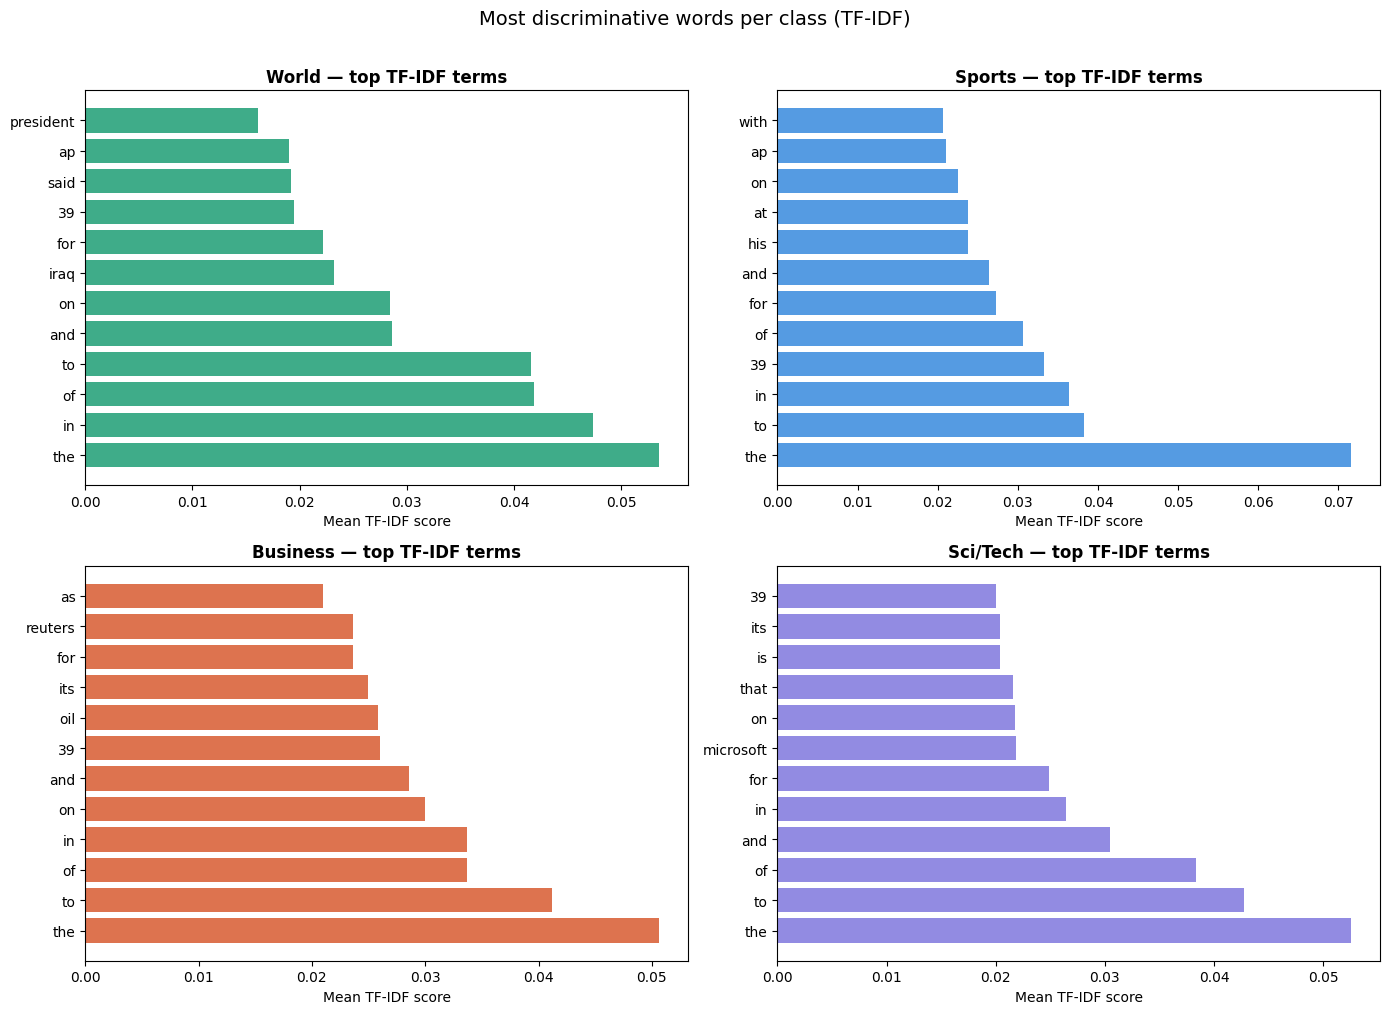

Saved to data/tfidf_top_words.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ["#1D9E75", "#378ADD", "#D85A30", "#7F77DD"]

for label_id, label_name in LABEL_MAP.items():
    class_mask  = y_train == label_id
    class_matrix = X_train[class_mask]
    mean_tfidf  = np.asarray(class_matrix.mean(axis=0)).flatten()
    top_indices = np.argsort(mean_tfidf)[-12:]
    top_words   = [vocab[i] for i in top_indices]
    top_scores  = [mean_tfidf[i] for i in top_indices]
    
    ax = axes[label_id]
    bars = ax.barh(top_words, top_scores, color=colors[label_id], alpha=0.85)
    ax.set_title(f"{label_name} — top TF-IDF terms", fontweight="bold")
    ax.set_xlabel("Mean TF-IDF score")
    ax.invert_yaxis()

plt.suptitle("Most discriminative words per class (TF-IDF)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/tfidf_top_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/tfidf_top_words.png")

In [12]:
# This block teaches you to think about vectorizer choices
configs = [
    {"max_features": 1000,  "ngram_range": (1,1), "label": "1k unigrams"},
    {"max_features": 10000, "ngram_range": (1,1), "label": "10k unigrams"},
    {"max_features": 10000, "ngram_range": (1,2), "label": "10k unigrams+bigrams"},
    {"max_features": 10000, "ngram_range": (1,1), "stop_words": "english", "label": "10k + stopword removal"},
]

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

print(f"\n{'Config':<35} {'F1 (macro)'}")
print("-" * 50)

for cfg in configs:
    label = cfg.pop("label")
    vec   = TfidfVectorizer(**cfg)
    Xtr   = vec.fit_transform(train_df["text"])
    Xte   = vec.transform(test_df["text"])
    lr    = LogisticRegression(max_iter=1000, C=1.0)
    lr.fit(Xtr, y_train)
    f1 = f1_score(lr.predict(Xte), y_test, average="macro")
    print(f"{label:<35} {f1:.4f}")
    cfg["label"] = label  # restore for re-use


Config                              F1 (macro)
--------------------------------------------------
1k unigrams                         0.8619
10k unigrams                        0.9134
10k unigrams+bigrams                0.9091
10k + stopword removal              0.9123


In [13]:
import pickle, os
os.makedirs("../model/artifacts", exist_ok=True)

# Use the config that performed best in Block 6
best_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True   # log(1+tf) instead of raw tf — standard practice
)
X_train_final = best_vectorizer.fit_transform(train_df["text"])
X_test_final  = best_vectorizer.transform(test_df["text"])

with open("../model/artifacts/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(best_vectorizer, f)

# Save transformed matrices too — Day 3 loads these directly
import scipy.sparse as sp
sp.save_npz("../data/X_train_tfidf.npz", X_train_final)
sp.save_npz("../data/X_test_tfidf.npz",  X_test_final)

print("Saved vectorizer and transformed matrices")
print(f"Final matrix shape: {X_train_final.shape}")

Saved vectorizer and transformed matrices
Final matrix shape: (120000, 10000)
